In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis

In [2]:
FS = 12000
WINDOW_SECONDS = 1
N_SAMPLES = FS * WINDOW_SECONDS

BPFI_MULT = 5.4152
BPFO_MULT = 3.5848
FTF_MULT = 0.39828
BSF_MULT = 4.7135

In [3]:
file_path = "../data/raw/CWRU/NORMAL_0.mat"

data = loadmat(file_path)

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X097_DE_time', 'X097_FE_time', 'X097RPM'])


In [4]:
de_keys = [
    key for key in data.keys()
    if "DE_time" in key
]

rpm_keys = [
    key for key in data.keys()
    if "RPM" in key
]

print("DE:", de_keys)
print("RPM:", rpm_keys)

DE: ['X097_DE_time']
RPM: ['X097RPM']


In [5]:
vibration = data[
    de_keys[0]
].squeeze()

rpm = float(
    np.asarray(
        data[rpm_keys[0]]
    ).squeeze()
)

signal = vibration[:N_SAMPLES]

print("RPM:", rpm)
print("Samples:", len(signal))

RPM: 1796.0
Samples: 12000


In [6]:
N = len(signal)

fft_values = rfft(signal)

frequencies = rfftfreq(
    N,
    d=1 / FS
)

magnitude = np.abs(
    fft_values
)

In [7]:
running_frequency = rpm / 60
physics_frequencies = {
    "1x": running_frequency,
    "2x": 2 * running_frequency,
    "3x": 3 * running_frequency,

    "BPFI": BPFI_MULT * running_frequency,
    "BPFO": BPFO_MULT * running_frequency,
    "FTF": FTF_MULT * running_frequency,
    "BSF": BSF_MULT * running_frequency
}

In [8]:
for name, frequency in physics_frequencies.items():
    print(
        f"{name}: {frequency:.2f} Hz"
    )

1x: 29.93 Hz
2x: 59.87 Hz
3x: 89.80 Hz
BPFI: 162.09 Hz
BPFO: 107.31 Hz
FTF: 11.92 Hz
BSF: 141.09 Hz


In [9]:
def spectral_energy(
    frequencies,
    magnitude,
    center_frequency,
    bandwidth=5
):

    lower = center_frequency - bandwidth
    upper = center_frequency + bandwidth

    mask = (
        (frequencies >= lower)
        &
        (frequencies <= upper)
    )

    energy = np.sum(
        magnitude[mask] ** 2
    )

    return energy

In [10]:
energy_1x = spectral_energy(
    frequencies,
    magnitude,
    physics_frequencies["1x"]
)

energy_2x = spectral_energy(
    frequencies,
    magnitude,
    physics_frequencies["2x"]
)

energy_3x = spectral_energy(
    frequencies,
    magnitude,
    physics_frequencies["3x"]
)

In [11]:
energy_bpfi = spectral_energy(
    frequencies,
    magnitude,
    physics_frequencies["BPFI"]
)

energy_bpfo = spectral_energy(
    frequencies,
    magnitude,
    physics_frequencies["BPFO"]
)

energy_ftf = spectral_energy(
    frequencies,
    magnitude,
    physics_frequencies["FTF"]
)

energy_bsf = spectral_energy(
    frequencies,
    magnitude,
    physics_frequencies["BSF"]
)

In [13]:
rms = np.sqrt(
    np.mean(signal ** 2)
)
variance = np.var(signal)
kurt = kurtosis(
    signal,
    fisher=False
)
peak = np.max(
    np.abs(signal)
)

crest_factor = peak / rms
peak_to_peak = (
    np.max(signal)
    -
    np.min(signal)
)

In [14]:
features = {
    "RMS": rms,
    "Variance": variance,
    "Kurtosis": kurt,
    "Crest_Factor": crest_factor,
    "Peak_to_Peak": peak_to_peak,

    "Energy_1x": energy_1x,
    "Energy_2x": energy_2x,
    "Energy_3x": energy_3x,

    "Energy_BPFI": energy_bpfi,
    "Energy_BPFO": energy_bpfo,
    "Energy_FTF": energy_ftf,
    "Energy_BSF": energy_bsf
}

In [15]:
for name, value in features.items():
    print(
        f"{name}: {value:.6f}"
    )

RMS: 0.074082
Variance: 0.005353
Kurtosis: 2.869599
Crest_Factor: 3.683347
Peak_to_Peak: 0.520287
Energy_1x: 309.244831
Energy_2x: 671.825264
Energy_3x: 5204.385359
Energy_BPFI: 16241.260928
Energy_BPFO: 4360.307900
Energy_FTF: 7.644515
Energy_BSF: 3909.052674


In [16]:
features["file"] = "NORMAL_0.mat"
features["class"] = "Healthy"
features["RPM"] = rpm

In [17]:
feature_df = pd.DataFrame(
    [features]
)

feature_df

,RMS,Variance,Kurtosis,Crest_Factor,Peak_to_Peak,Energy_1x,Energy_2x,Energy_3x,Energy_BPFI,Energy_BPFO,Energy_FTF,Energy_BSF,file,class,RPM
0,0.074082,0.005353,2.869599,3.683347,0.520287,309.244831,671.825264,5204.385359,16241.260928,4360.3079,7.644515,3909.052674,NORMAL_0.mat,Healthy,1796.0


In [18]:
from pathlib import Path

CWRU_PATH = Path(
    "../data/raw/CWRU"
)

files = sorted(
    CWRU_PATH.glob("*.mat")
)

print("Files found:", len(files))

for file in files:
    print(file.name)

Files found: 16
B007_0.mat
B007_1.mat
B007_2.mat
B007_3.mat
IR007_0.mat
IR007_1.mat
IR007_2.mat
IR007_3.mat
NORMAL_0.mat
NORMAL_1.mat
NORMAL_2.mat
NORMAL_3.mat
OR007@6_0.mat
OR007@6_1.mat
OR007@6_2.mat
OR007@6_3.mat


In [19]:
def get_class(filename):

    if filename.startswith("NORMAL"):
        return "Healthy"

    elif filename.startswith("IR007"):
        return "Inner Race"

    elif filename.startswith("B007"):
        return "Ball"

    elif filename.startswith("OR007"):
        return "Outer Race"

    else:
        return "Unknown"

In [35]:
output_path = (
    "../data/processed/CWRU/"
    "cwru_physics_features.csv"
)

feature_df.to_csv(
    output_path,
    index=False
)

print(
    "Saved:",
    output_path
)


Saved: ../data/processed/CWRU/cwru_physics_features.csv


In [54]:
def get_de_signals(data):

    de_keys = [
        key for key in data.keys()
        if key.endswith("_DE_time")
    ]

    return de_keys

In [55]:
def get_rpm_for_signal(data, signal_key):

    prefix = signal_key.split("_DE_time")[0]

    rpm_key = prefix + "RPM"

    if rpm_key in data:

        rpm = float(
            np.asarray(
                data[rpm_key]
            ).squeeze()
        )

        return rpm

    return np.nan

In [56]:
all_features = []

for file in files:

    data = loadmat(file)

    de_keys = get_de_signals(data)

    if not de_keys:

        print(
            "Skipping - no DE signal:",
            file.name
        )

        continue

    for de_key in de_keys:

        vibration = np.asarray(
            data[de_key]
        ).squeeze()

        if len(vibration) < N_SAMPLES:

            print(
                "Skipping - insufficient samples:",
                file.name,
                de_key
            )

            continue

        signal = vibration[:N_SAMPLES]

        rpm = get_rpm_for_signal(
            data,
            de_key
        )

        print(
            "Processing:",
            file.name,
            de_key,
            "RPM:",
            rpm
        )

Processing: B007_0.mat X118_DE_time RPM: 1796.0
Processing: B007_1.mat X119_DE_time RPM: 1772.0
Processing: B007_2.mat X120_DE_time RPM: 1748.0
Processing: B007_3.mat X121_DE_time RPM: 1722.0
Processing: IR007_0.mat X105_DE_time RPM: 1797.0
Processing: IR007_1.mat X106_DE_time RPM: 1772.0
Processing: IR007_2.mat X107_DE_time RPM: 1748.0
Processing: IR007_3.mat X108_DE_time RPM: 1721.0
Processing: NORMAL_0.mat X097_DE_time RPM: 1796.0
Processing: NORMAL_1.mat X098_DE_time RPM: nan
Processing: NORMAL_2.mat X098_DE_time RPM: nan
Processing: NORMAL_2.mat X099_DE_time RPM: nan
Processing: NORMAL_3.mat X100_DE_time RPM: 1725.0
Processing: OR007@6_0.mat X130_DE_time RPM: 1796.0
Processing: OR007@6_1.mat X131_DE_time RPM: 1773.0
Processing: OR007@6_2.mat X132_DE_time RPM: 1750.0
Processing: OR007@6_3.mat X133_DE_time RPM: 1725.0


In [57]:
rms = np.sqrt(
    np.mean(signal ** 2)
)

variance = np.var(signal)

kurt = kurtosis(
    signal,
    fisher=False
)

peak = np.max(
    np.abs(signal)
)

crest_factor = peak / rms

peak_to_peak = (
    np.max(signal)
    -
    np.min(signal)
)

In [58]:
features = {

    "source_file": file.name,

    "signal_id": de_key.replace(
        "_DE_time",
        ""
    ),

    "class": get_class(
        file.name
    ),

    "RPM": rpm,

    "RMS": rms,

    "Variance": variance,

    "Kurtosis": kurt,

    "Crest_Factor": crest_factor,

    "Peak_to_Peak": peak_to_peak
}

In [59]:
N = len(signal)

fft_values = rfft(signal)

frequencies = rfftfreq(
    N,
    d=1 / FS
)

magnitude = np.abs(
    fft_values
)

In [65]:
print(
    feature_df[
        [
            "source_file",
            "signal_id",
            "class",
            "RPM"
        ]
    ]
)

     source_file signal_id       class     RPM
0  OR007@6_3.mat      X133  Outer Race  1725.0


In [74]:
all_features = []

for file in files:

    data = loadmat(file)

    de_keys = [
        key for key in data.keys()
        if key.endswith("_DE_time")
    ]

    if not de_keys:
        print("Skipping - no DE signal:", file.name)
        continue

    for de_key in de_keys:

        vibration = np.asarray(
            data[de_key]
        ).squeeze()

        if len(vibration) < N_SAMPLES:
            print(
                "Skipping - insufficient samples:",
                file.name,
                de_key
            )
            continue

        signal = vibration[:N_SAMPLES]

        # Find corresponding RPM
        rpm = get_rpm_for_signal(
            data,
            de_key
        )

        # FFT
        N = len(signal)

        fft_values = rfft(signal)

        frequencies = rfftfreq(
            N,
            d=1 / FS
        )

        magnitude = np.abs(
            fft_values
        )

        # Time-domain features
        rms = np.sqrt(
            np.mean(signal ** 2)
        )

        variance = np.var(signal)

        kurt = kurtosis(
            signal,
            fisher=False
        )

        peak = np.max(
            np.abs(signal)
        )

        crest_factor = peak / rms

        peak_to_peak = (
            np.max(signal)
            - np.min(signal)
        )

        features = {
            "source_file": file.name,

            "signal_id": de_key.replace(
                "_DE_time",
                ""
            ),

            "class": get_class(
                file.name
            ),

            "RPM": rpm,

            "RMS": rms,

            "Variance": variance,

            "Kurtosis": kurt,

            "Crest_Factor": crest_factor,

            "Peak_to_Peak": peak_to_peak
        }

        # Physics features only when RPM exists
        if not np.isnan(rpm):

            running_frequency = rpm / 60

            physics_frequencies = {

                "1x": running_frequency,

                "2x": 2 * running_frequency,

                "3x": 3 * running_frequency,

                "BPFI":
                    BPFI_MULT *
                    running_frequency,

                "BPFO":
                    BPFO_MULT *
                    running_frequency,

                "FTF":
                    FTF_MULT *
                    running_frequency,

                "BSF":
                    BSF_MULT *
                    running_frequency
            }

            features["Energy_1x"] = spectral_energy(
                frequencies,
                magnitude,
                physics_frequencies["1x"]
            )

            features["Energy_2x"] = spectral_energy(
                frequencies,
                magnitude,
                physics_frequencies["2x"]
            )

            features["Energy_3x"] = spectral_energy(
                frequencies,
                magnitude,
                physics_frequencies["3x"]
            )

            features["Energy_BPFI"] = spectral_energy(
                frequencies,
                magnitude,
                physics_frequencies["BPFI"]
            )

            features["Energy_BPFO"] = spectral_energy(
                frequencies,
                magnitude,
                physics_frequencies["BPFO"]
            )

            features["Energy_FTF"] = spectral_energy(
                frequencies,
                magnitude,
                physics_frequencies["FTF"]
            )

            features["Energy_BSF"] = spectral_energy(
                frequencies,
                magnitude,
                physics_frequencies["BSF"]
            )

        else:

            features["Energy_1x"] = np.nan
            features["Energy_2x"] = np.nan
            features["Energy_3x"] = np.nan

            features["Energy_BPFI"] = np.nan
            features["Energy_BPFO"] = np.nan
            features["Energy_FTF"] = np.nan
            features["Energy_BSF"] = np.nan

        all_features.append(features)

        print(
            "Processed:",
            file.name,
            de_key,
            "RPM:",
            rpm
        )

Processed: B007_0.mat X118_DE_time RPM: 1796.0
Processed: B007_1.mat X119_DE_time RPM: 1772.0
Processed: B007_2.mat X120_DE_time RPM: 1748.0
Processed: B007_3.mat X121_DE_time RPM: 1722.0
Processed: IR007_0.mat X105_DE_time RPM: 1797.0
Processed: IR007_1.mat X106_DE_time RPM: 1772.0
Processed: IR007_2.mat X107_DE_time RPM: 1748.0
Processed: IR007_3.mat X108_DE_time RPM: 1721.0
Processed: NORMAL_0.mat X097_DE_time RPM: 1796.0
Processed: NORMAL_1.mat X098_DE_time RPM: nan
Processed: NORMAL_2.mat X098_DE_time RPM: nan
Processed: NORMAL_2.mat X099_DE_time RPM: nan
Processed: NORMAL_3.mat X100_DE_time RPM: 1725.0
Processed: OR007@6_0.mat X130_DE_time RPM: 1796.0
Processed: OR007@6_1.mat X131_DE_time RPM: 1773.0
Processed: OR007@6_2.mat X132_DE_time RPM: 1750.0
Processed: OR007@6_3.mat X133_DE_time RPM: 1725.0


In [75]:
feature_df = pd.DataFrame(
    all_features
)

print(
    "Rows:",
    len(feature_df)
)

print(
    "Columns:",
    len(feature_df.columns)
)

Rows: 17
Columns: 16


In [76]:
display(
    feature_df[
        [
            "source_file",
            "signal_id",
            "class",
            "RPM"
        ]
    ]
)

,source_file,signal_id,class,RPM
0,B007_0.mat,X118,Ball,1796.0
1,B007_1.mat,X119,Ball,1772.0
2,B007_2.mat,X120,Ball,1748.0
3,B007_3.mat,X121,Ball,1722.0
4,IR007_0.mat,X105,Inner Race,1797.0
5,IR007_1.mat,X106,Inner Race,1772.0
6,IR007_2.mat,X107,Inner Race,1748.0
7,IR007_3.mat,X108,Inner Race,1721.0
8,NORMAL_0.mat,X097,Healthy,1796.0
9,NORMAL_1.mat,X098,Healthy,NaN


In [77]:
duplicates = feature_df[
    feature_df.duplicated(
        subset=[
            "source_file",
            "signal_id"
        ],
        keep=False
    )
]

display(duplicates)

,source_file,signal_id,class,RPM,RMS,Variance,Kurtosis,Crest_Factor,Peak_to_Peak,Energy_1x,Energy_2x,Energy_3x,Energy_BPFI,Energy_BPFO,Energy_FTF,Energy_BSF


In [78]:
print(
    feature_df["class"].value_counts()
)

class
Healthy       5
Ball          4
Inner Race    4
Outer Race    4
Name: count, dtype: int64


In [79]:
class_table = feature_df[
    [
        "source_file",
        "signal_id",
        "class",
        "RPM"
    ]
].sort_values(
    ["class", "source_file", "signal_id"]
)

display(class_table)

,source_file,signal_id,class,RPM
0,B007_0.mat,X118,Ball,1796.0
1,B007_1.mat,X119,Ball,1772.0
2,B007_2.mat,X120,Ball,1748.0
3,B007_3.mat,X121,Ball,1722.0
8,NORMAL_0.mat,X097,Healthy,1796.0
9,NORMAL_1.mat,X098,Healthy,NaN
10,NORMAL_2.mat,X098,Healthy,NaN
11,NORMAL_2.mat,X099,Healthy,NaN
12,NORMAL_3.mat,X100,Healthy,1725.0
4,IR007_0.mat,X105,Inner Race,1797.0


In [84]:
output_path = "../data/processed/CWRU/cwru_physics_features.csv"

feature_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: ../data/processed/CWRU/cwru_physics_features.csv


In [85]:
print(
    feature_df.isnull().sum()
)

source_file     0
signal_id       0
class           0
RPM             3
RMS             0
Variance        0
Kurtosis        0
Crest_Factor    0
Peak_to_Peak    0
Energy_1x       3
Energy_2x       3
Energy_3x       3
Energy_BPFI     3
Energy_BPFO     3
Energy_FTF      3
Energy_BSF      3
dtype: int64


In [86]:
time_features = [
    "RMS",
    "Variance",
    "Kurtosis",
    "Crest_Factor",
    "Peak_to_Peak"
]

In [87]:
print(time_features)

['RMS', 'Variance', 'Kurtosis', 'Crest_Factor', 'Peak_to_Peak']


In [88]:
feature_df[
    time_features
].describe()

,RMS,Variance,Kurtosis,Crest_Factor,Peak_to_Peak
count,17.000000,17.000000,17.000000,17.000000,17.000000
mean,0.265260,0.112622,4.641468,4.409673,2.499756
std,0.212264,0.149878,2.078425,0.827514,2.277683
min,0.064424,0.003967,2.724532,3.461846,0.439344
25%,0.074082,0.005353,2.925184,3.678552,0.520287
50%,0.154805,0.023953,2.983638,4.030328,1.233532
75%,0.312346,0.097539,5.632106,5.209852,3.037050
max,0.676408,0.456391,8.053920,5.477161,6.760144


In [89]:
class_means = feature_df.groupby(
    "class"
)[time_features].mean()

display(class_means)

,RMS,Variance,Kurtosis,Crest_Factor,Peak_to_Peak
class,,,,,
Ball,0.143968,0.020700,2.876419,3.753991,1.068945
Healthy,0.066984,0.004357,2.916736,3.603714,0.462417
Inner Race,0.298149,0.088893,5.443613,5.229344,2.841924
Outer Race,0.601507,0.363601,7.760287,5.253133,6.135073


In [92]:
from pathlib import Path

figure_path = Path(
    "../data/processed/CWRU/figures"
)

figure_path.mkdir(
    parents=True,
    exist_ok=True
)

<Figure size 800x500 with 0 Axes>

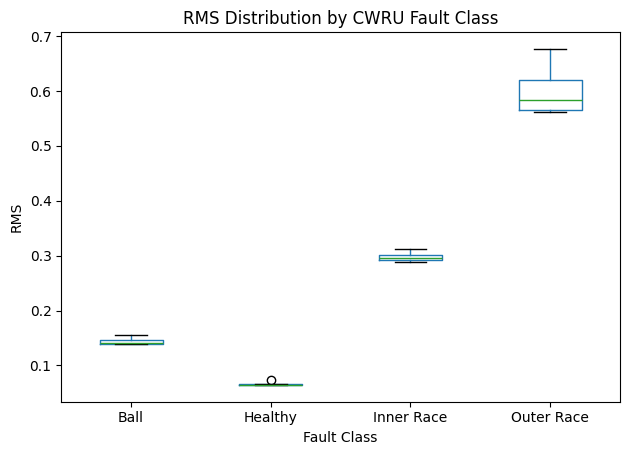

<Figure size 800x500 with 0 Axes>

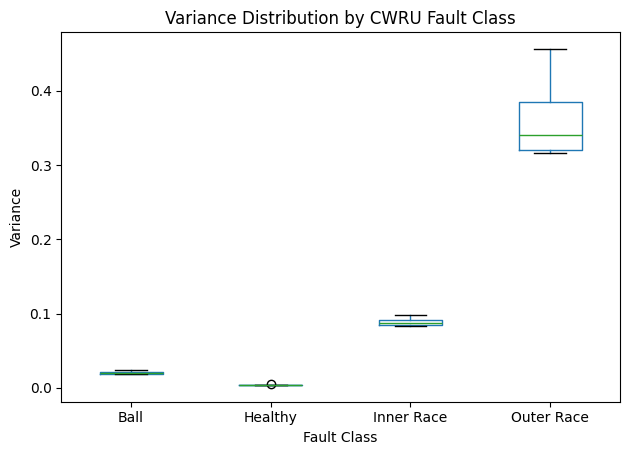

<Figure size 800x500 with 0 Axes>

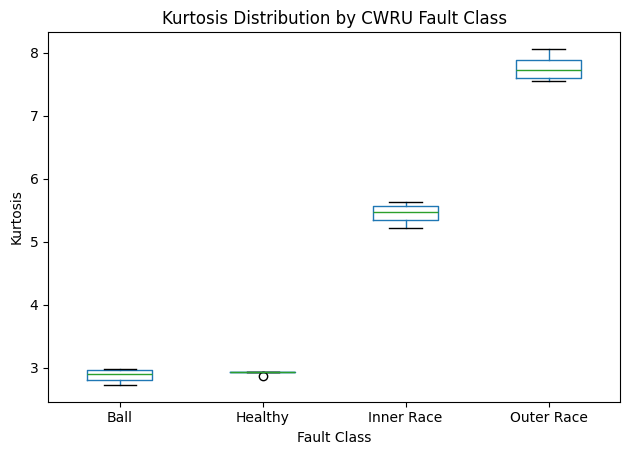

<Figure size 800x500 with 0 Axes>

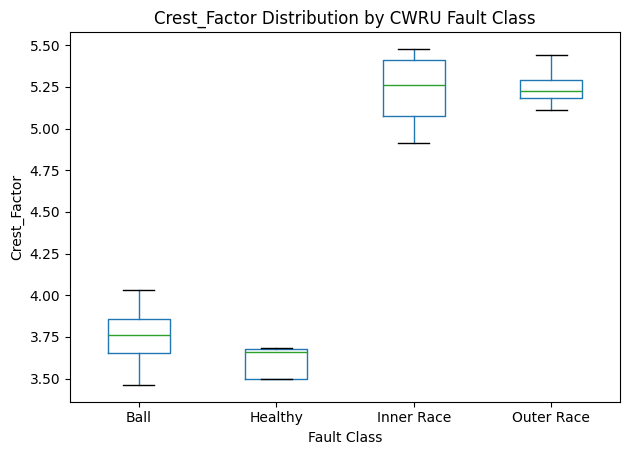

<Figure size 800x500 with 0 Axes>

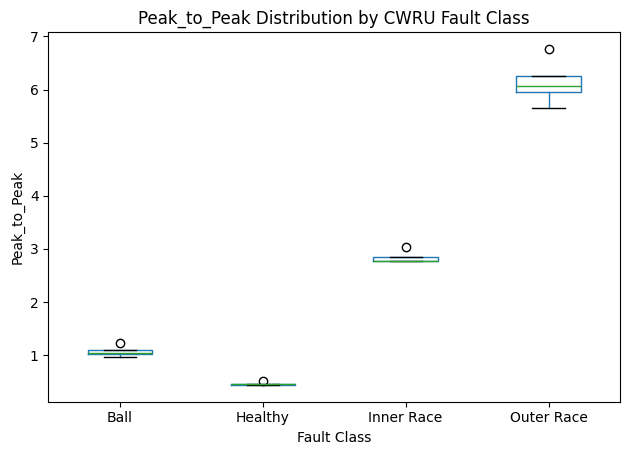

In [93]:
for feature in time_features:

    plt.figure(figsize=(8, 5))

    feature_df.boxplot(
        column=feature,
        by="class"
    )

    plt.title(
        f"{feature} Distribution by CWRU Fault Class"
    )

    plt.suptitle("")

    plt.xlabel("Fault Class")
    plt.ylabel(feature)

    plt.grid()

    plt.tight_layout()

    filename = (
        "boxplot_"
        + feature
        + ".png"
    )

    plt.savefig(
        figure_path / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [94]:
feature_df.to_csv(
    "../data/processed/CWRU/cwru_physics_features.csv",
    index=False
)

print(
    "Physics feature dataset saved successfully."
)

Physics feature dataset saved successfully.
